# работа над ошибками
### часть 6

Я переанализировал что я сделал и понял что есть моменты где я почти "втер лажу":

наши эмбеддинги контекстные!!!! — вектор сообщения строится из него самого + reply-предков
+ пары соседей!!!!. значит соседние сообщения имеют скоррелированные векторы ПО ПОСТРОЕНИЮ,
классификатор даёт им скоррелированные метки => скоррелированные ошибки. тогда почти все
красивые факты про грамматику, память и тд могут быть артефактом эмбеддера, а не
свойством чата(

Четко проверим насколько все критично

где без независимой разметки не обойтись - запускалась LLM 

суммари: тест А (автокорр векторов), тест Б (LLM-разметка), циклы/сток, скип others, parent-kid информация на независимых метках

Импорты

In [1]:
import os, json
while not os.path.isdir("chats"): os.chdir("..")
import numpy as np, pandas as pd, seaborn as sns
sns.set_theme(style="whitegrid", palette="deep", rc={"figure.figsize": (8, 4.5)})

df = pd.read_csv("chats/physics/df.csv", parse_dates=["ts"])
d = df[~df["is_bot"]].reset_index(drop=True)      
cats = sorted(d["mega"].unique()); K = len(cats)
codes = d["mega"].map({c: i for i, c in enumerate(cats)}).to_numpy()
sess = d["session"].to_numpy()

In [2]:
#оценка взаимной информации (копипаст из предыдущего)
def MI(a, b, K):
    T = np.zeros((K, K)); np.add.at(T, (a, b), 1); P = T / T.sum()
    Pi, Pj = P.sum(1, keepdims=True), P.sum(0, keepdims=True); m = P > 0
    return float((P[m] * np.log2(P[m] / (Pi * Pj)[m])).sum())

## 1. посмотрим на автокорреляцию самих векторов

идея простая: если степенная память меток I(d) — это есть автокорреляция контекстных векторов, 

то r(d) = ⟨cos(v_t, v_(t+d))⟩ должна падать сравномо с этим

давайте просто посчитаем ассимптотики этих связей


In [3]:
ids = json.load(open("chats/physics/vec/ids_ctx.json")); rowv = {u: i for i, u in enumerate(ids)}
B = np.load("chats/physics/vec/dense_ctx.f16.npy").astype(np.float32); B /= np.linalg.norm(B, axis=1, keepdims=True) + 1e-9
Bs = B[[rowv[u] for u in d["unit_id"]]]   

In [4]:
deltas = np.unique(np.round(np.logspace(0, np.log10(len(codes)//100), 26)).astype(int))
rho = np.array([float((Bs[:-x] * Bs[x:]).sum(1).mean()) for x in deltas])
I = np.array([MI(codes[:-x], codes[x:], K) for x in deltas])

In [8]:
g = pd.DataFrame({"log(d)": np.log(np.r_[deltas, deltas]), "log(val)": np.log(np.r_[I, rho]),
                  "type": ["I(d)"]*len(deltas) + ["r(d)"]*len(deltas)})
g

,log(d),log(val),type
0,0.000000,-0.583345,I(d)
1,0.693147,-0.923028,I(d)
2,1.098612,-1.259543,I(d)
3,1.386294,-1.726540,I(d)
4,1.609438,-1.867500,I(d)
5,1.945910,-2.118461,I(d)
6,2.302585,-2.409985,I(d)
7,2.564949,-2.642162,I(d)
8,2.833213,-2.859567,I(d)
9,3.091042,-3.123901,I(d)


<Axes: xlabel='log(d)', ylabel='log(val)'>

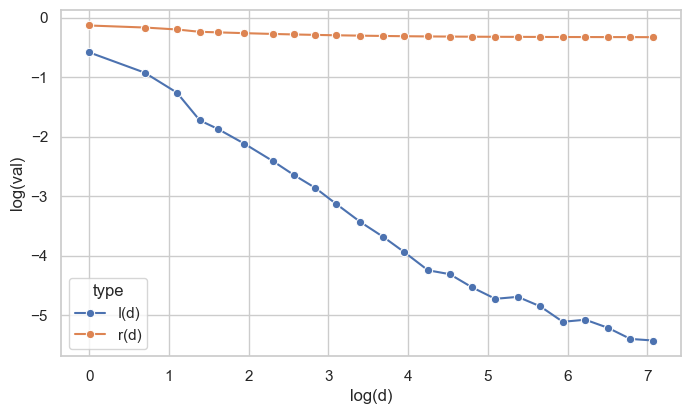

In [9]:
sns.lineplot(data=g, x="log(d)", y="log(val)", hue="type", marker="o")

In [10]:
#r(d) почти плоская (или очень медленная), I(d) падает по степени много быстрее чем r(d)
#наклоны разные => память меток НЕ автокорреляция эмбеддера
#ошибки не было

### 2. еще одна разметка LLM

эмбеддер везде один и тот же - альтернативную проверку логично даёт только другая разметка.

потому:
завайбкодим LLM чтоб она делала следущее:

непрерывный блок 5000 сообщений (репрезентативный, период января когда активность)
разметить локально моделью RuadaptQwen3-4B 

каждому сообщению давался текст + контекст (предыдущие реплики, reply + n соседей) и просил выбрать 1 из 7 тем, эти метки **вообще не касаются эмбеддингов** — модель читает текст

теперь пересчитаем грамматику/память/вспышечность на ЕЕ метках против линейной на том же
блоке

In [11]:
meta = pd.read_csv("chats/physics/topics/blockB_meta.csv")
llm = {r["unit_id"]: r["megas"][0] for r in map(json.loads, open("chats/physics/topics/blockB_labeled.jsonl"))}
meta["llm"] = meta["unit_id"].map(llm)
print("block len", len(meta), "| совпадение LLM и линмодели:", round((meta["mega"] == meta["llm"]).mean(), 2))
meta[["mega", "llm"]].head(6)

block len 5000 | совпадение LLM и линмодели: 0.4


,mega,llm
0,Оффтоп/болтовня,Оффтоп/болтовня
1,Поступление и подготовка,others
2,Оффтоп/болтовня,others
3,Оффтоп/болтовня,others
4,Оффтоп/болтовня,others
5,Разбор задач,others


<Axes: >

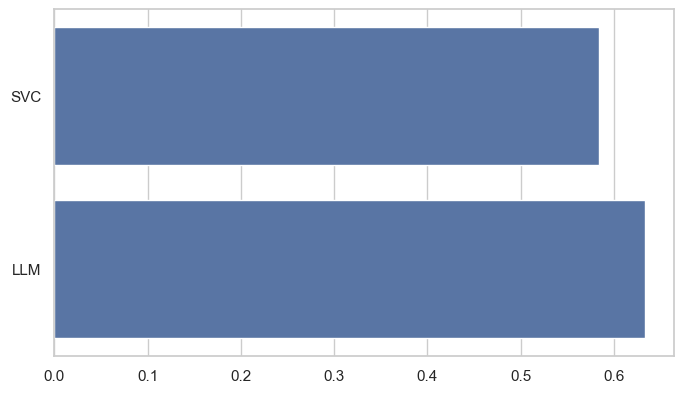

In [14]:
#gemini перепроверила взаимную информацию в reply цепях (грамматика 2 порядок которая) {
allc = sorted(set(meta["mega"]) | set(meta["llm"])); ix = {c: i for i, c in enumerate(allc)}
inblk = set(meta["unit_id"])
def replyMI(col):
    lab = dict(zip(meta["unit_id"], meta[col])); p, c = [], []
    for uid, pu in zip(meta["unit_id"], meta["reply_to_unit"]):
        if pu in inblk:
            p.append(ix[lab[pu]]); c.append(ix[lab[uid]])
    return MI(np.array(p), np.array(c), len(allc))
#}
sns.barplot(x=[replyMI("mega"), replyMI("llm")], y=["SVC", "LLM"])

In [15]:
#Имеем SVC 0.58, LLM 0.63 -ТЕ на независимых метках не меньше, а даже БОЛЬШЕЕЕ!
#=> грамматика реальна, не артефакт факта что родитель в векторе. мы ее даже занижали изза шума

память I(d) на малых d — тоже на обеих разметках

<Axes: xlabel='d', ylabel='I'>

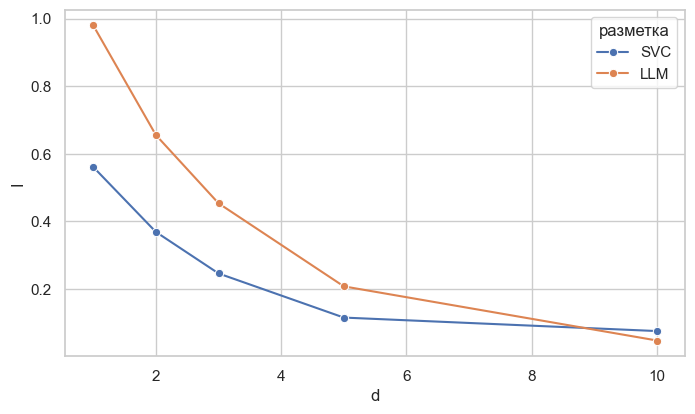

In [16]:
def blkI(col):
    code = meta.sort_values("ts")[col].map(ix).to_numpy()
    return [MI(code[:-x], code[x:], len(allc)) for x in [1, 2, 3, 5, 10]]
g = pd.DataFrame({"d": [1,2,3,5,10]*2, "I": blkI("mega") + blkI("llm"),
                  "разметка": ["SVC"]*5 + ["LLM"]*5})
sns.lineplot(data=g, x="d", y="I", hue="разметка", marker="o")

In [ ]:
#та же спадающая память, у LLM в ближней зоне даже сильнее - воспроизводится

## 3. степень I(d) плывёт (тут был фейк)

в части 3 вывод сделан как ОДИН степенной закон I(d) ~ d^-0.73, на самом деле показатель не
постоянный

посмотрим локальный наклон по участкам d

In [17]:
grid = np.unique(np.round(np.logspace(0, np.log10(len(codes)//100), 40)).astype(int))
Ig = np.array([MI(codes[:-x], codes[x:], K) for x in grid])
lg, lI = np.log(grid), np.log(Ig)
ranges = [(1,10),(10,60),(60,300),(300,1200)]
loc = [np.polyfit(lg[(grid>=a)&(grid<=b)], lI[(grid>=a)&(grid<=b)], 1)[0] for a,b in ranges]
loc

[np.float64(-0.8435387569186762),
 np.float64(-0.9606910987098494),
 np.float64(-0.43986871949852885),
 np.float64(-0.2654283840846864)]

<Axes: >

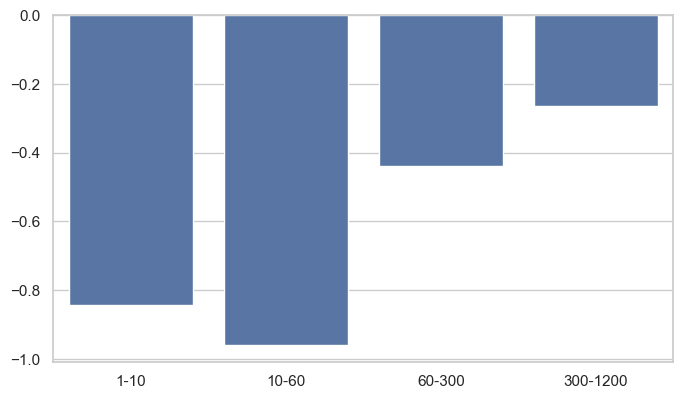

In [18]:
sns.barplot(x=[f"{a}-{b}" for a,b in ranges], y=loc)

In [20]:
#наклон меняется излом на d=60 - те масштаб имеется все таки(
#крутой спад внутри сессии + пологий межсессионный хвост, а не один закон

#но так как степень все равно >-1 то интегральная сумма все равно расходится 
# и информация бесконечно расти может

## 4. строго почему нет циклов в марковской матрице

+откуда берутся потоки - если есть сообщение как родитель и как ребенок - можно посмотреть как они распределены и посмотреть кто что производит больше и откуда куда почему все идет

<Axes: xlabel='part', ylabel='topic'>

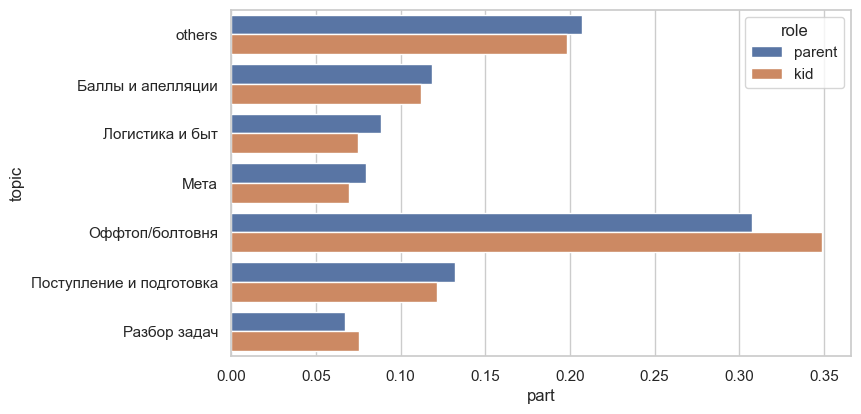

In [21]:
par = d.set_index("unit_id")["mega"]; e = d[d["reply_to_unit"] >= 0].copy()
e["p"] = e["reply_to_unit"].map(par); e = e.dropna(subset=["p"])
src = e["p"].map({c:i for i,c in enumerate(cats)}).to_numpy(); dst = e["mega"].map({c:i for i,c in enumerate(cats)}).to_numpy()
T = np.zeros((K,K)); np.add.at(T,(src,dst),1); F = T/T.sum()
g = pd.DataFrame({"topic": cats*2, "part": np.r_[F.sum(1), F.sum(0)],
                  "role": ["parent"]*K + ["kid"]*K})
sns.barplot(data=g, x="part", y="topic", hue="role")

In [22]:
#тут как раз видно в основном только offtop больше как ответ
# потому именно засчет это разницы поток от parent->kid часто идет именно в offtop
#это и есть так называемый сток

# 5) а есть ли циклы? смотрим пока длины 3

In [29]:
#vibe coded {
import itertools

J = 0.5 * (F - F.T)

tri = []
for i, j, k in itertools.combinations(range(K), 3):
    circ = J[i, j] + J[j, k] + J[k, i]
    tri.append((abs(circ), f"{cats[i]} -> {cats[j]} -> {cats[k]}"))
tri.sort(reverse=True)

quad = []
for i, j, k, l in itertools.permutations(range(K), 4):
    if i != min(i, j, k, l) or j > l:
        continue
    circ = J[i, j] + J[j, k] + J[k, l] + J[l, i]
    quad.append((abs(circ), f"{cats[i]} -> {cats[j]} -> {cats[k]} -> {cats[l]}"))
quad.sort(reverse=True)

print("sum|J| =", round(np.abs(J).sum(), 4))
print("max 3-cycle =", round(tri[0][0], 4), "|", tri[0][1])
print("max 4-cycle =", round(quad[0][0], 4), "|", quad[0][1])

b = F.sum(1) - F.sum(0)
acyclic = np.abs(b).sum() / 2
print("исток->сток (не в цикл):", round(acyclic, 4))
print("в циклах:", round(1 - acyclic, 4))  
#}

sum|J| = 0.0569
max 3-cycle = 0.0037 | Логистика и быт -> Оффтоп/болтовня -> Разбор задач
max 4-cycle = 0.0039 | others -> Оффтоп/болтовня -> Логистика и быт -> Разбор задач
исток->сток (не в цикл): 0.0498
в циклах: 0.9502


In [ ]:
#sum|J| = 0.0569 - это вроде мы еще давно померили сумма модулей расхождения в матрице ассиметрии
#95% потока принадлежит циклу мне кажется это завышенная величина - типа цикл длины 1? 2? 
# надо пересчитать, а то несодержательно

In [31]:
#gemini {
diag    = np.trace(F)                             # длина 1 (петли)
two     = np.minimum(F, F.T).sum() - diag         # длина 2
acyclic = np.abs(F.sum(1) - F.sum(0)).sum() / 2   # исток->сток, не в цикл
cyc_gt2 = 1 - diag - two - acyclic                # всё остальное = циклы >2

print("len 1 (петли):", round(diag, 4))
print("len 2        :", round(two, 4))
print("len >2       :", round(cyc_gt2, 4), f"= {100*cyc_gt2:.2f}%")
print("acyclic      :", round(acyclic, 4))
# }   

len 1 (петли): 0.5828
len 2        : 0.3603
len >2       : 0.0071 = 0.71%
acyclic      : 0.0498


##### а вот это уже нормально интерпретируется - то есть есть много петель и пар, а также немного стоков

но глобально циклических больших движений нет!!!

## 6. индивидуальность не из-за эмбеддингов

показатель отношения корреляции упорядоченности сообщений обычных и перемешанных из ноутбука про эргодичность - далее будет f (был равен 9) - мог быть раздут коррелированными ошибками эмбеддера

но тип речи и тип контента (лежат в df) сделаны через регулярные выражения (вайбкод), без эмбеддера. 

если там f >> 1 - индивидуальность сто процентов в реальности

In [25]:
# gemini:
def f(dd, col):
    cc = sorted(dd[col].unique()); Kc = len(cc); code = dd[col].map({x:i for i,x in enumerate(cc)}).to_numpy()
    auth = dd["author_id"].to_numpy(); pbar = np.bincount(code, minlength=Kc)/len(code)
    u, inv = np.unique(auth, return_inverse=True); Cm = np.zeros((len(u), Kc)); np.add.at(Cm, (inv, code), 1)
    E = Cm.sum(1, keepdims=True)*pbar; return float(np.where(E>0,(Cm-E)**2/E,0).sum()/((len(u)-1)*(Kc-1)))

#}

<Axes: xlabel='f', ylabel='метка'>

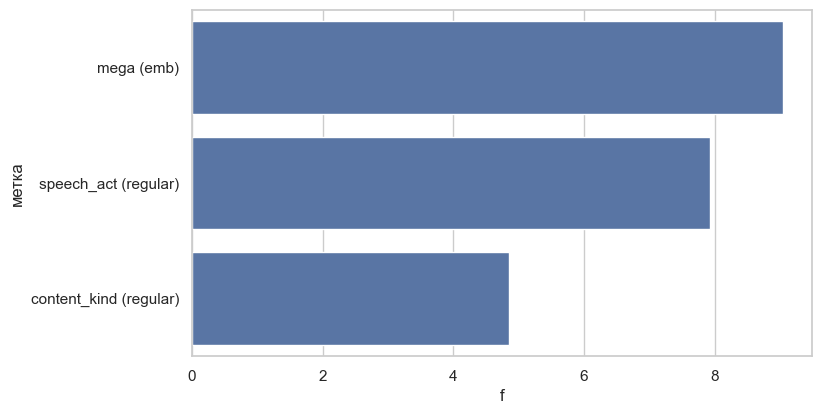

In [24]:
g = pd.DataFrame({"метка": ["mega (emb)", "speech_act (regular)", "content_kind (regular)"],
                  "f": [f(d, "mega"), f(d, "speech_act"), f(d, "content_kind")]})
sns.barplot(data=g, x="f", y="метка")

In [ ]:
#f(speech_act)=7.9, f(content_kind)=4.9 - это много больше единицы, на метках БЕЗ эмбеддера
# индивидуальность реальна но показатель чучуть завышен

#+важно отменить что у нас не эргодичность нарушена а система как единое целое не выполняется
#есть умные теоремы из динамики которые говорят что система распадается на компоненты 
# каждая из которых эргодична локально, то есть пользователи бьются на устойчивые группы 
# но это уже слишком сложно и надо будет отдельно все это исследовать

## итоги работы над ошибками

1) память НЕ автокорреляция эмбеддера✅
2) грамматика и корреляции parent-kid в темах реальна ✅
3) индивидуальный характер пользователя f >> 1 (но чучуть завышен)✅ 
4) Циклов тем нет + понятно откуда берется переход в offtop✅ 
5) единый степенной закон на всех d ❌

короче засейвились